<a href="https://colab.research.google.com/github/mariapeguerosolv-cmd/Actividad6/blob/main/Actividad_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Instrucciones**

**Deberás seleccionar un problema de clasificación (clínico, financiero o social) y establecer un objetivo SMART para evaluar el desempeño de un modelo de aprendizaje automático. La actividad debe cumplir con los siguientes elementos:**


2.	**Notebook o script de experimentación.**

**Contenido:**

* Código del modelo.
*	Cálculo de métricas.
* Validación cruzada.
* Ajuste de umbral.
* Implementación de pruebas A/B.
* Evidencia de experimentos.


In [31]:
# 0. CONFIGURACIÓN INICIAL Y DEPENDENCIAS

# Clonar repositorio
!git clone https://github.com/mariapeguerosolv-cmd/Actividad6.git
%cd Actividad6

# Configurar usuario de Git
!git config --global user.name "Maria"
!git config --global user.email "maria.pegueros.olv@gmail.com"

# Librerías
!pip install mlflow xgboost pyngrok skops -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, label_binarize, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve
)

from xgboost import XGBClassifier
import mlflow
import mlflow.sklearn

# Configurar experimento en MLflow
mlflow.set_experiment("Prediccion_Riesgo_Clientes_Actividad6")

# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

Cloning into 'Actividad6'...
remote: Enumerating objects: 51, done.
remote: Counting objects: 100% (51/51), done.
remote: Compressing objects: 100% (39/39), done.
remote: Total 51 (delta 6), reused 28 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (51/51), 102.92 KiB | 1.56 MiB/s, done.
Resolving deltas: 100% (6/6), done.
/content/Actividad6/Actividad6/Actividad6


2026/06/28 01:55:29 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/28 01:55:29 INFO mlflow.store.db.utils: Updating database tables
2026/06/28 01:55:31 INFO mlflow.tracking.fluent: Experiment with name 'Prediccion_Riesgo_Clientes_Actividad6' does not exist. Creating a new experiment.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
# 1. CARGA Y PREPROCESAMIENTO DE DATOS

filepath = ('/content/drive/MyDrive/Inteligencia Artificial/5to Tetra: Gestión de Proyectos de IA/Modulo 2/Semana 7/Tarea/dataset_predictive_collection.csv')
df = pd.read_csv(filepath).fillna(0)

# Variables predictoras y target original
X = df.drop("riesgo", axis=1)
y = df["riesgo"]

# Codificación de variables categóricas (Predictoras)
X = pd.get_dummies(X, drop_first=True)

# Codificación estricta del Target (Multiclase) para evitar conflictos de tipo
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# División de datos (Train/Test) manteniendo la proporción de clases
X_train, X_test, y_train_encoded, y_test_encoded = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [33]:
# 2. ANÁLISIS EXPLORATORIO DE DATOS (EDA)

print("=== 1. REVISAR ESTRUCTURA DEL DATASET ===")
print("Primeras filas del dataset:")
print(df.head())

print("\nColumnas del dataset:")
print(df.columns.tolist())

print("\nInformación del dataset:")
df.info()

print("\nEstadísticas descriptivas:")
print(df.describe(include="all"))

print("\n=== 2. ANÁLISIS DE VALORES ÚNICOS Y DISTRIBUCIÓN ===")
for col in df.columns:
    print(f"\nColumna: {col}")
    print("Valores únicos:", df[col].unique()[:10])

print("\nDistribución de la variable 'riesgo':")
print(df["riesgo"].value_counts())
print(f"Mapeo interno: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print("\nDistribución de la variable 'sentiment_email':")
print(df["sentiment_email"].value_counts())

print("\nDistribución de la variable 'accion_recomendada':")
print(df["accion_recomendada"].value_counts())

print("\n=== 3. DETECCIÓN RÁPIDA DE SESGOS ===")
print("\nPromedio de días de atraso por nivel de riesgo:")
print(df.groupby("riesgo")["dias_atraso"].mean())

print("\nPromedio de monto de factura por nivel de riesgo:")
print(df.groupby("riesgo")["monto_factura"].mean())

print("\nDistribución de riesgo según sentimiento de email:")
print(pd.crosstab(df["sentiment_email"], df["riesgo"]))

=== 1. REVISAR ESTRUCTURA DEL DATASET ===
Primeras filas del dataset:
  id_cliente id_factura  monto_factura  dias_atraso  historial_pago  \
0        C70      F0001          39547            9              16   
1       C199      F0002          13627           27              10   
2       C163      F0003          31207            9              10   
3       C310      F0004           7572            5              10   
4       C306      F0005          23859           17              11   

   frecuencia_disputas sentiment_email  riesgo accion_recomendada  \
0                    0        negative  medium           reminder   
1                    0        negative    high               call   
2                    2         neutral  medium           reminder   
3                    0        positive     low          statement   
4                    1         neutral    high           reminder   

  fecha_factura  
0    2026-06-30  
1    2026-06-17  
2    2026-05-15  
3    2026-05-04 

In [34]:
# 3. BASELINE (Modelo Trivial)

print("\n=== 4. BASELINE ===")
valores, conteos = np.unique(y_train_encoded, return_counts=True)
clase_mayoritaria = valores[np.argmax(conteos)]

y_pred_baseline = np.full_like(y_test_encoded, fill_value=clase_mayoritaria)
baseline_acc = accuracy_score(y_test_encoded, y_pred_baseline)
print("Baseline Accuracy:", baseline_acc)


=== 4. BASELINE ===
Baseline Accuracy: 0.55


In [35]:
# 4. REGRESIÓN LOGÍSTICA

print("\n=== 5. REGRESIÓN LOGÍSTICA ===")
with mlflow.start_run(run_name="Logistic_Regression"):
    # Escalado de datos para entrenamiento y evaluación estándar
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    log_reg = LogisticRegression(max_iter=1000, random_state=42)
    log_reg.fit(X_train_scaled, y_train_encoded)

    y_pred_log = log_reg.predict(X_test_scaled)
    y_prob_log = log_reg.predict_proba(X_test_scaled)

    # Métricas
    acc_log = accuracy_score(y_test_encoded, y_pred_log)
    prec_log = precision_score(y_test_encoded, y_pred_log, average="weighted")
    rec_log = recall_score(y_test_encoded, y_pred_log, average="weighted")
    f1_log = f1_score(y_test_encoded, y_pred_log, average="weighted")
    roc_auc_log = roc_auc_score(y_test_encoded, y_prob_log, multi_class="ovr", average="weighted")

    # Corrección metodológica: Validación cruzada protegida con Pipeline
    pipeline_log = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42))
    cv_acc_log = cross_val_score(pipeline_log, X, y_encoded, cv=5, scoring="accuracy").mean()

    print(f"Accuracy: {acc_log:.4f} | CV Accuracy: {cv_acc_log:.4f} | F1-Score: {f1_log:.4f}")

    # Registro en MLflow
    mlflow.log_param("model", "LogisticRegression")
    mlflow.log_metric("accuracy", acc_log)
    mlflow.log_metric("precision", prec_log)
    mlflow.log_metric("recall", rec_log)
    mlflow.log_metric("f1", f1_log)
    mlflow.log_metric("roc_auc", roc_auc_log)
    mlflow.log_metric("cv_accuracy", cv_acc_log)
    mlflow.sklearn.log_model(log_reg, name="logistic_regression")


=== 5. REGRESIÓN LOGÍSTICA ===
Accuracy: 0.6200 | CV Accuracy: 0.6310 | F1-Score: 0.5680


In [36]:
# 5. XGBOOST (Optimizado con GridSearchCV)

print("\n=== 6. XGBOOST ===")
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 6],
    "learning_rate": [0.05, 0.1]
}

grid = GridSearchCV(
    XGBClassifier(eval_metric="mlogloss", random_state=42),
    param_grid,
    cv=5,
    scoring="f1_weighted"
)

grid.fit(X_train, y_train_encoded)
best_xgb = grid.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)

with mlflow.start_run(run_name="XGBoost"):
    acc_xgb = accuracy_score(y_test_encoded, y_pred_xgb)
    prec_xgb = precision_score(y_test_encoded, y_pred_xgb, average="weighted")
    rec_xgb = recall_score(y_test_encoded, y_pred_xgb, average="weighted")
    f1_xgb = f1_score(y_test_encoded, y_pred_xgb, average="weighted")
    roc_auc_xgb = roc_auc_score(y_test_encoded, y_prob_xgb, multi_class="ovr", average="weighted")

    print(f"Accuracy: {acc_xgb:.4f} | F1-Score: {f1_xgb:.4f} | Mejor Parámetro: {grid.best_params_}")

    mlflow.log_param("model", "XGBoost")
    mlflow.log_params(grid.best_params_)
    mlflow.log_metric("accuracy", acc_xgb)
    mlflow.log_metric("precision", prec_xgb)
    mlflow.log_metric("recall", rec_xgb)
    mlflow.log_metric("f1", f1_xgb)
    mlflow.log_metric("roc_auc", roc_auc_xgb)
    mlflow.sklearn.log_model(
        best_xgb,
        name="xgboost",
        skops_trusted_types=['xgboost.core.Booster', 'xgboost.sklearn.XGBClassifier']
    )



=== 6. XGBOOST ===
Accuracy: 0.8375 | F1-Score: 0.8347 | Mejor Parámetro: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}


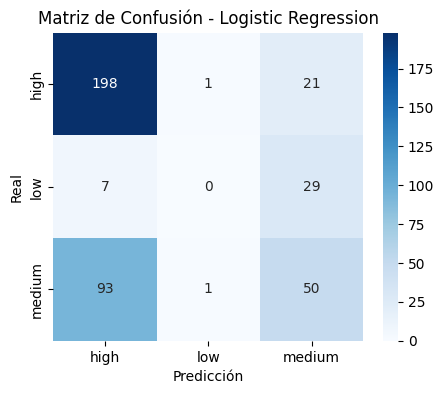

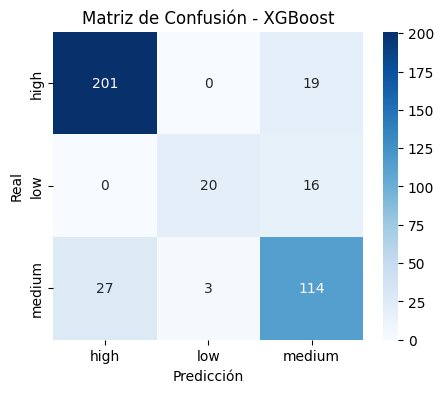

In [37]:
# 6. MATRICES DE CONFUSIÓN

def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(title)
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.show()

plot_confusion(y_test_encoded, y_pred_log, "Matriz de Confusión - Logistic Regression")
plot_confusion(y_test_encoded, y_pred_xgb, "Matriz de Confusión - XGBoost")

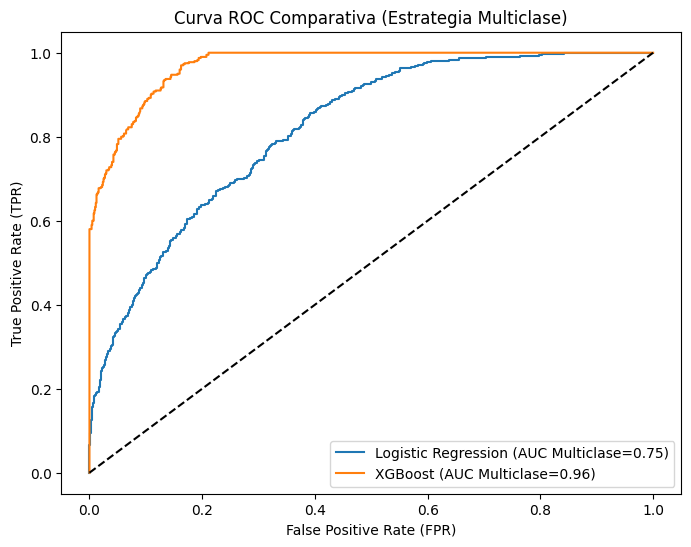

In [38]:
# 7. CURVA ROC COMPARATIVA (Multiclase OvR)

n_classes = len(le.classes_)
y_test_bin = label_binarize(y_test_encoded, classes=range(n_classes))

plt.figure(figsize=(8,6))
fpr_log, tpr_log, _ = roc_curve(y_test_bin.ravel(), y_prob_log.ravel())
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC Multiclase={roc_auc_log:.2f})")

fpr_xgb, tpr_xgb, _ = roc_curve(y_test_bin.ravel(), y_prob_xgb.ravel())
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC Multiclase={roc_auc_xgb:.2f})")

plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Curva ROC Comparativa (Estrategia Multiclase)")
plt.legend()
plt.show()

In [39]:
# 8. AJUSTE DE UMBRAL (Optimización de Costos Financieros)

def predict_with_threshold_multiclass(probs, target_class_idx, weight):
    modified_probs = probs.copy()
    modified_probs[:, target_class_idx] *= weight
    return np.argmax(modified_probs, axis=1)

print("\n=== 7. AJUSTE DE UMBRAL MULTICLASE (Optimización de Recall para Clase de Alto Riesgo) ===")
pesos_sensibilidad = [1.0, 1.5, 2.2]
for w in pesos_sensibilidad:
    y_pred_thr = predict_with_threshold_multiclass(y_prob_log, target_class_idx=2, weight=w)
    print(f"Factor de peso {w} -> Weighted Recall Global: {recall_score(y_test_encoded, y_pred_thr, average='weighted', zero_division=0):.4f}")


=== 7. AJUSTE DE UMBRAL MULTICLASE (Optimización de Recall para Clase de Alto Riesgo) ===
Factor de peso 1.0 -> Weighted Recall Global: 0.6200
Factor de peso 1.5 -> Weighted Recall Global: 0.6250
Factor de peso 2.2 -> Weighted Recall Global: 0.6200


In [40]:
# 9. SIMULACIÓN DE PRUEBAS A/B

print("\n=== 8. SIMULACIÓN DE PRUEBA A/B (Impacto Financiero) ===")
y_pred_ab_A = predict_with_threshold_multiclass(y_prob_log, target_class_idx=2, weight=1.0)
y_pred_ab_B = predict_with_threshold_multiclass(y_prob_log, target_class_idx=2, weight=1.5)

print(f"Grupo A (Modelo Default) - Recall: {recall_score(y_test_encoded, y_pred_ab_A, average='weighted'):.4f}")
print(f"Grupo B (Umbral Ajustado) - Recall: {recall_score(y_test_encoded, y_pred_ab_B, average='weighted'):.4f}")


=== 8. SIMULACIÓN DE PRUEBA A/B (Impacto Financiero) ===
Grupo A (Modelo Default) - Recall: 0.6200
Grupo B (Umbral Ajustado) - Recall: 0.6250


In [41]:
# 10. COMPARACIÓN FINAL Y MÉTRICAS

print("\n=== 9. TABLA COMPARATIVA FINAL ===")
comparacion = pd.DataFrame({
    "Modelo": ["Baseline Trivial", "Logistic Regression", "XGBoost"],
    "Accuracy": [baseline_acc, acc_log, acc_xgb],
    "F1-Score (Weighted)": [0, f1_log, f1_xgb],
    "ROC_AUC (Weighted OvR)": [0, roc_auc_log, roc_auc_xgb]
})

print(comparacion)


=== 9. TABLA COMPARATIVA FINAL ===
                Modelo  Accuracy  F1-Score (Weighted)  ROC_AUC (Weighted OvR)
0     Baseline Trivial    0.5500             0.000000                0.000000
1  Logistic Regression    0.6200             0.568004                0.746630
2              XGBoost    0.8375             0.834680                0.961114


In [42]:
# ==========================================
# PRUEBAS PRÁCTICAS CON NUEVOS CLIENTES
# ==========================================
clientes_prueba = pd.DataFrame([
    {"monto_factura":500,"dias_atraso":0,"historial_pago":1,"frecuencia_disputas":0,
     "sentiment_email_negative":0,"sentiment_email_neutral":1,"sentiment_email_positive":0,"riesgo":"high"},
    {"monto_factura":25000,"dias_atraso":18,"historial_pago":5,"frecuencia_disputas":1,
     "sentiment_email_negative":1,"sentiment_email_neutral":0,"sentiment_email_positive":0,"riesgo":"high"},
    {"monto_factura":12000,"dias_atraso":7,"historial_pago":12,"frecuencia_disputas":2,
     "sentiment_email_negative":0,"sentiment_email_neutral":0,"sentiment_email_positive":1,"riesgo":"high"},
    {"monto_factura":3000000,"dias_atraso":0,"historial_pago":223,"frecuencia_disputas":0,
     "sentiment_email_negative":0,"sentiment_email_neutral":0,"sentiment_email_positive":1,"riesgo":"low"},
    {"monto_factura":8000,"dias_atraso":10,"historial_pago":15,"frecuencia_disputas":0,
     "sentiment_email_negative":0,"sentiment_email_neutral":0,"sentiment_email_positive":1,"riesgo":"high"}
])

# 1. Alinear columnas con las variables predictoras (X)
clientes_prueba_proc = pd.DataFrame(0, index=clientes_prueba.index, columns=X.columns)
for col in clientes_prueba.columns:
    if col in clientes_prueba_proc.columns:
        clientes_prueba_proc[col] = clientes_prueba[col]

# 2. Preparar variables reales (y_true) y aplicar escalador para Regresión Logística
y_true = clientes_prueba["riesgo"].values
clientes_prueba_scaled = scaler.transform(clientes_prueba_proc)

# 3. Realizar predicciones numéricas
y_pred_log_numeric = log_reg.predict(clientes_prueba_scaled)
y_pred_xgb_numeric = best_xgb.predict(clientes_prueba_proc) # XGBoost no requiere escala

# 4. Traducir números de vuelta a texto original ("high", "low", "medium")
y_pred_log = le.inverse_transform(y_pred_log_numeric)
y_pred_xgb = le.inverse_transform(y_pred_xgb_numeric)

# 5. Desplegar resultados y reportes
print("Resultados de Predicción:")
print("Reales:             ", y_true)
print("Regresión Logística:", y_pred_log)
print("XGBoost:            ", y_pred_xgb)

print("\n=== REPORTE DE EVALUACIÓN: REGRESIÓN LOGÍSTICA ===")
print(classification_report(y_true, y_pred_log, zero_division=0))

print("\n=== REPORTE DE EVALUACIÓN: XGBOOST ===")
print(classification_report(y_true, y_pred_xgb, zero_division=0))

Resultados de Predicción:
Reales:              ['high' 'high' 'high' 'low' 'high']
Regresión Logística: ['medium' 'high' 'medium' 'medium' 'medium']
XGBoost:             ['low' 'high' 'medium' 'low' 'low']

=== REPORTE DE EVALUACIÓN: REGRESIÓN LOGÍSTICA ===
              precision    recall  f1-score   support

        high       1.00      0.25      0.40         4
         low       0.00      0.00      0.00         1
      medium       0.00      0.00      0.00         0

    accuracy                           0.20         5
   macro avg       0.33      0.08      0.13         5
weighted avg       0.80      0.20      0.32         5


=== REPORTE DE EVALUACIÓN: XGBOOST ===
              precision    recall  f1-score   support

        high       1.00      0.25      0.40         4
         low       0.33      1.00      0.50         1
      medium       0.00      0.00      0.00         0

    accuracy                           0.40         5
   macro avg       0.44      0.42      0.30      